In [1]:
#Librerias utilizadas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import time
import math
import glob
from pathlib import Path

In [ ]:
directory = "./csvs/results/*.csv"
verbose = 0

# Read all the results tables in the directory
csv_files = glob.glob(directory)

# Sort the tables by name
csv_files = sorted(csv_files)

# Read all the csv files from the directory, and save we save them in a list
dataframes = [pd.read_csv(f) for f in csv_files]
names_frames = [Path(csv).stem.split('_')[0] for csv in csv_files]
dimensions_problems = []
print(names_frames)

# We print the tables readed
if verbose == 0:
    for i in range(0, len(csv_files)):
        print(f"|{i}| The table has been read it from the directory: {csv_files[i]}")
    print("-"*80)
if verbose in [0,1]:
    print(f"{len(dataframes)} tables has been readed.")


['ARGLINA', 'BARD', 'BEALE', 'BRKMCC', 'BROWNAL', 'BROWNBS', 'BROWNDEN', 'CHNROSNB', 'CLIFF', 'CUBE', 'DECONVU', 'DENSCHNA', 'DENSCHNB', 'DENSCHNC', 'DENSCHND', 'DENSCHNF', 'DIXON3DQ', 'EIGENALS', 'EIGENBLS', 'ENGVAL2', 'EXTROSNB', 'FLETCBV2', 'FLETCHCR', 'GENHUMPS', 'HAIRY', 'HEART6LS', 'HELIX', 'HILBERTA', 'HILBERTB', 'HIMMELBB', 'HIMMELBH', 'HUMPS', 'JENSMP', 'KOWOSB', 'LOGHAIRY', 'MANCINO', 'MARATOSB', 'MEXHAT', 'PALMER1C', 'PALMER2C', 'PALMER3C', 'PALMER4C', 'PALMER5C', 'PALMER6C', 'PALMER7C', 'PALMER8C', 'POWELLSQ', 'ROSENBR', 'SINEVAL', 'SISSER', 'TOINTQOR', 'VARDIM', 'WATSON', 'YFITU']
|0| The table has been read it from the directory: ./csvs/results/ARGLINA_none.csv
|1| The table has been read it from the directory: ./csvs/results/BARD_none.csv
|2| The table has been read it from the directory: ./csvs/results/BEALE_none.csv
|3| The table has been read it from the directory: ./csvs/results/BRKMCC_none.csv
|4| The table has been read it from the directory: ./csvs/results/BROWNAL

In [39]:
# We have 5 methods and 4 variables, then in total we have N \times 5 elements in the dataframe
result_matrix = np.zeros((4, len(dataframes), 5))

col_names = ["Oviedo", "Grads", "Random", "Newton", "BFGS"]
for i in range(0, len(dataframes)):
    itterations = dataframes[i]["iterations"].to_numpy()
    grads = dataframes[i]["Last Gradient"].to_numpy()
    exc = dataframes[i]["Execution time"].to_numpy()
    ittPSec = dataframes[i]["Iterations per Second"].to_numpy()
    result_matrix[:, i, :] = [itterations, grads, exc, ittPSec]


scientific_notation = True
default_values = [1000, 0, np.inf, np.inf]


for w in [3]:
    max_intValue = default_values[w]
    for (i, problem) in enumerate(names_frames):
        if w in [0, 1, 2]:
            print(problem, end=" & ")
        if w in [0,1,2]:
            best_value_index = result_matrix[w, i, :].argmin()
        else:
            best_value_index = result_matrix[w, i, :].argmax()
        for j in range(0, 5):
            try:
                value = result_matrix[w, i, j]
                
                if value == 0.0:
                    exponent = 0
                    decimal = 0
                else:
                    exponent = int(math.floor(math.log10(abs(value))))
                    decimal = value / (10 ** exponent)

            
                # Decidimos si resaltamos el valor (HL) o no
                if j == best_value_index and value != max_intValue:
                    # Lógica para el MEJOR valor
                    if -1 <= exponent <= 3:
                        # Si es entero, quitamos decimales, si no, usamos 3
                        content = "{0:d}".format(int(value)) if value.is_integer() else "{0:.4f}".format(value)
                        print("{{$\\bs{{{}}}$}}".format(content), end="")
                    else:
                        print("\\tableHL{{{0:.4f}}}{{{1}}}".format(decimal, exponent), end="")
                
                else:
                    # Lógica para valores NORMALES
                    if -1 <= exponent <= 3:
                        content = "{0:d}".format(int(value)) if value.is_integer() else "{0:.4f}".format(value)
                        print("{{{}}}".format(content), end="")
                    else:
                        print("{:.4f}e{}".format(decimal, exponent), end="")

                # Separador de columnas o fin de línea
                if j == 4:
                    print("\\\\", end="\n")
                else:
                    print(" & ", end="")
            except:
                print(value, end="\n")
        # # Format the number first
        # if j == best_value_index:
        #     # We use double backslashes so Python treats them as literal text
        #     value = f"\\textbf{{{v:4.5e}}}"
        # else:
        #     value = f"{v:4.5e}"
        
        # # Print the formatted value with the correct ending
        # if j == 3: 
        #     print(value, end=" \\\\\n")
        # else:
        #     print(value, end=" & ")

{17.6476} & {2.9388} & {$\bs{33.9016}$} & {22.5568} & {33.3700}\\
{188.5733} & {163.7841} & 1.0000e5 & {342.6595} & \tableHL{1.6670}{5}\\
{2138.2688} & {2761.4235} & \tableHL{1.8598}{5} & {73.8902} & {9510.8934}\\
{16.0495} & {43.6124} & \tableHL{6.3873}{4} & {153.1928} & 3.1242e4\\
{9.1041} & {27.7219} & {66.7688} & {52.3474} & {$\bs{346.1942}$}\\
{51.7349} & {344.3635} & \tableHL{1.1111}{5} & {9916.9378} & 9.0877e4\\
{95.2997} & {96.9766} & 6.7243e4 & {341.1174} & \tableHL{1.1045}{5}\\
{2606.4804} & {5767.2451} & 1.3436e4 & {1276.1611} & \tableHL{2.0004}{4}\\
{108.3427} & {304.2390} & 1.6063e5 & {1061.9355} & \tableHL{2.3104}{5}\\
{35.5073} & 1.0219e4 & \tableHL{7.6260}{4} & {192.4935} & 3.3396e4\\
{2376.9176} & {3725.7136} & {$\bs{6059.7669}$} & {2487.3648} & {566.6115}\\
{24.0874} & {65.3188} & 9.3902e4 & {267.0851} & \tableHL{1.0072}{5}\\
{24.1092} & {65.6771} & \tableHL{9.8922}{4} & {1012.7183} & {21.0040}\\
{44.1753} & {120.5757} & \tableHL{1.1491}{5} & {421.7307} & {1846.9983}\

# Creation of a summary table


In [ ]:
cellcolors = ["\\cellcolor{blue!20}O", "\\cellcolor{red!20}G", "\\cellcolor{purple!20}R", "\\cellcolor{green!20}N", "\\cellcolor{yellow!20}B"]
indices_values = [[], [], [], []]
default_values = [1000, 0, np.inf, np.inf, np.inf]


for (i, problem) in enumerate(names_frames):
    print(problem, end=" & ")
    for w in range(0, 4):
        if w in [0,1,2]:
            best_value_index = result_matrix[w, i, :].argmin()
        else:
            best_value_index = result_matrix[w, i, :].argmax()
        if w != 3:
            print(cellcolors[best_value_index], end=" & ")
        else:
            print(cellcolors[best_value_index], end="")
        if result_matrix[w, i, best_value_index] != default_values[w]:
            indices_values[w].append(int(best_value_index))
    print("\\"+"\\")
    print(i)



ARGLINA & \cellcolor{blue!20}O & \cellcolor{yellow!20}B & \cellcolor{purple!20}R & \cellcolor{purple!20}R\\
0
BARD & \cellcolor{green!20}N & \cellcolor{red!20}G & \cellcolor{purple!20}R & \cellcolor{yellow!20}B\\
1
BEALE & \cellcolor{yellow!20}B & \cellcolor{green!20}N & \cellcolor{yellow!20}B & \cellcolor{purple!20}R\\
2
BRKMCC & \cellcolor{purple!20}R & \cellcolor{blue!20}O & \cellcolor{purple!20}R & \cellcolor{purple!20}R\\
3
BROWNAL & \cellcolor{blue!20}O & \cellcolor{red!20}G & \cellcolor{red!20}G & \cellcolor{yellow!20}B\\
4
BROWNBS & \cellcolor{purple!20}R & \cellcolor{blue!20}O & \cellcolor{purple!20}R & \cellcolor{purple!20}R\\
5
BROWNDEN & \cellcolor{purple!20}R & \cellcolor{red!20}G & \cellcolor{purple!20}R & \cellcolor{yellow!20}B\\
6
CHNROSNB & \cellcolor{green!20}N & \cellcolor{green!20}N & \cellcolor{yellow!20}B & \cellcolor{yellow!20}B\\
7
CLIFF & \cellcolor{blue!20}O & \cellcolor{red!20}G & \cellcolor{purple!20}R & \cellcolor{yellow!20}B\\
8
CUBE & \cellcolor{green!20}

In [10]:
dataframes[0].head()

,iterations,Last Gradient,Execution time
0,100.0,1.127926e-06,1.605030
1,100.0,9.284476e-05,1.541615
2,100.0,1.559949e-06,1.426855
3,15.0,4.684101e-09,0.291569


In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate synthetic data: 100 samples of an array of shape (1, 4)
# Each value in the array is randomly chosen from 0 to 4
varibles = ["Iterations", "Last Gradient", "Execution time", "Iterations per second"]

name_map = {
    0: 'Category A',
    1: 'Category B',
    2: 'Category C',
    3: 'Category D',
    4: 'Category E'
}
data_list = []
for i, sublist in enumerate(indices_values):
    for value in sublist:
        data_list.append({'Element': varibles[i], 'Label': name_map[value]})

df = pd.DataFrame(data_list)

# 3. Define specific color mapping
color_dict = {
    'Category A': 'blue',
    'Category B': 'red',
    'Category C': 'purple',
    'Category D': 'green',
    'Category E': 'orange'
}

# 4. Plotting
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df, 
    x='Element', 
    hue='Value', 
    palette=color_dict,
    hue_order=list(name_map.values())  # Keeps the legend and bars in consistent order
)

plt.title('Number of problems solved by each method')
plt.xlabel('Measurament')
plt.ylabel('Count')
plt.legend(title='Value', loc='upper left')
plt.tight_layout()

plt.show()

ValueError: Could not interpret value `Value` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

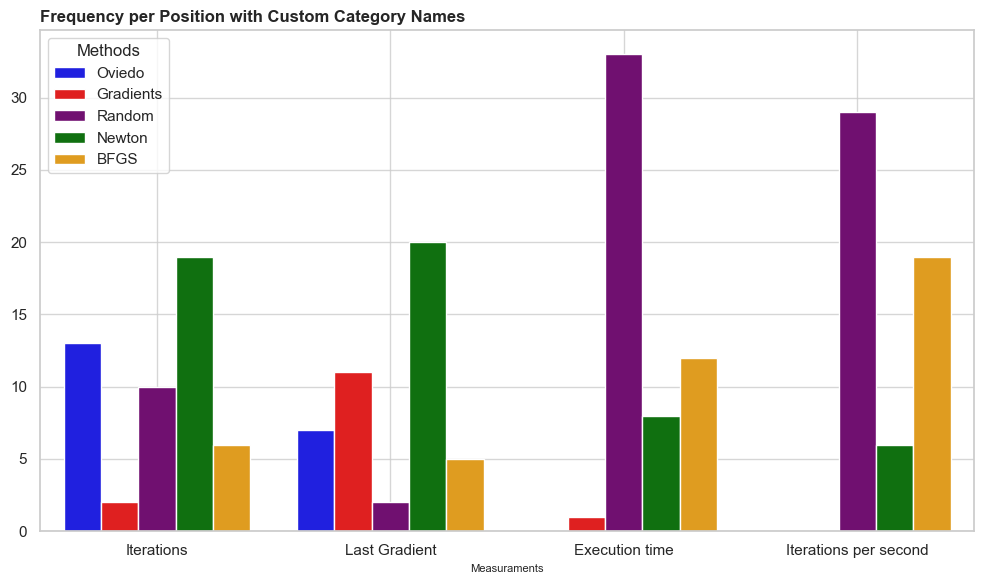

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Map values to your specific names
# Replace 'Name A', etc., with your actual category names
sns.set_theme(style="whitegrid")
name_map = {
    0: 'Oviedo',
    1: 'Gradients',
    2: 'Random',
    3: 'Newton',
    4: 'BFGS'
}
varibles = ["Iterations", "Last Gradient", "Execution time", "Iterations per second"]


# 3. Convert to Long-Format DataFrame and apply the names
data_list = []
for i, sublist in enumerate(indices_values):
    for value in sublist:
        data_list.append({
            'Element': varibles[i], 
            'Label': name_map[value]  # Use the name instead of the number
        })
df = pd.DataFrame(data_list)

# 4. Update the color dictionary to use the new names
color_dict = {
    'Oviedo': 'blue',
    'Gradients': 'red',
    'Random': 'purple',
    'Newton': 'green',
    'BFGS': 'orange'
}

# 5. Plotting
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df, 
    x='Element', 
    hue='Label', 
    palette=color_dict,
    hue_order=list(name_map.values()) # Keeps categories in order A -> E
)

plt.title('Frequency per Position with Custom Category Names', fontdict={"fontsize":12}, fontweight='bold', loc="left")
plt.xlabel('Measuraments', fontdict={"fontsize":8})
plt.ylabel('')
plt.grid(alpha=0.8)
plt.legend(title='Methods', loc='upper left')
plt.tight_layout()

#Save plot (For Poster)
#plt.savefig("images/countplot_solvedProblems.jpg", dpi=1200)

#Save plot (For thesis)
plt.savefig("images/countplot_solvedProblems.svg")
